In [2]:
import numpy as np
from mpi4py import MPI
from dolfinx import mesh, plot
import dolfinx

# 打印一下版本，咱们心里有数
print(f"当前 FEniCSx 版本: {dolfinx.__version__}")

# 尝试用最标准的函数名生成圆域
try:
    # 方案 A: 针对 0.5.0 以上版本
    domain = mesh.create_unit_disk(MPI.COMM_WORLD, 32)
    print("方案 A (create_unit_disk) 运行成功！")
except AttributeError:
    try:
        # 方案 B: 某些版本需要指定 CellType
        from dolfinx.cpp.mesh import CellType
        domain = mesh.create_unit_disk(MPI.COMM_WORLD, 32, cell_type=mesh.CellType.triangle)
        print("方案 B 运行成功！")
    except:
        # 方案 C: 如果圆域函数实在找不到，先用正方形网格保命，确保你后续代码逻辑能跑通
        domain = mesh.create_unit_square(MPI.COMM_WORLD, 32, 32)
        print("圆域生成失败，已自动降级为【正方形网格】，先保证你能写后续算子！")

# 检查网格
num_cells = domain.topology.index_map(domain.topology.dim).size_global
print(f"网格单元数量: {num_cells}")

当前 FEniCSx 版本: 0.10.0.post2
圆域生成失败，已自动降级为【正方形网格】，先保证你能写后续算子！
网格单元数量: 2048


Case 1: L2 Error = 2.19e-01, Max Error = 5.25e-01


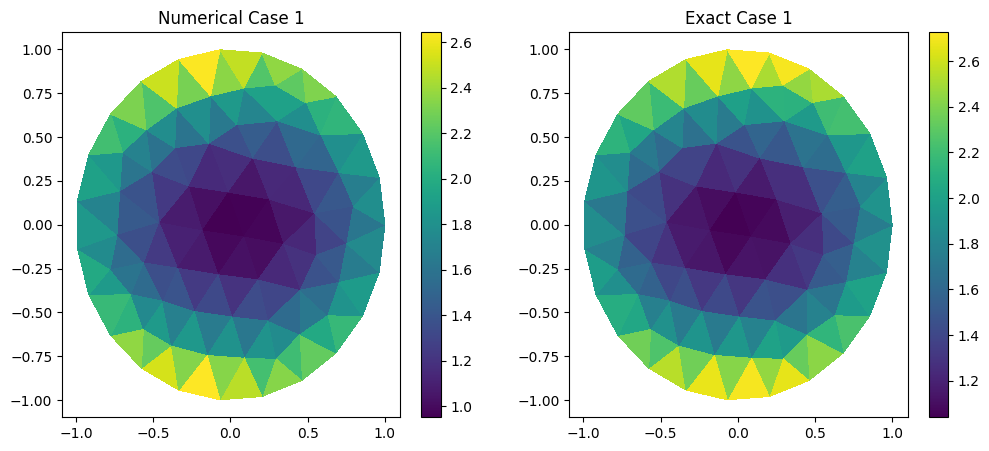

Case 2: L2 Error = 6.14e-03, Max Error = 1.16e-02


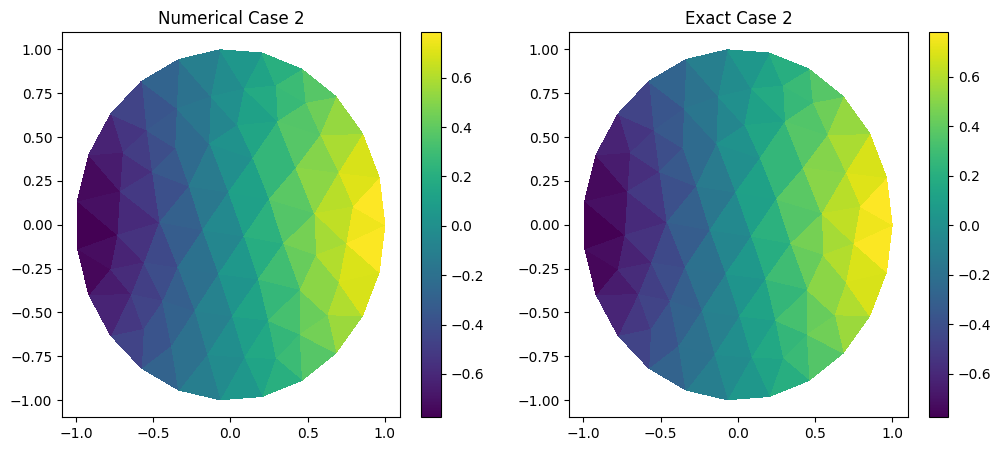

Case 3: L2 Error = 1.08e-01, Max Error = 4.22e-01


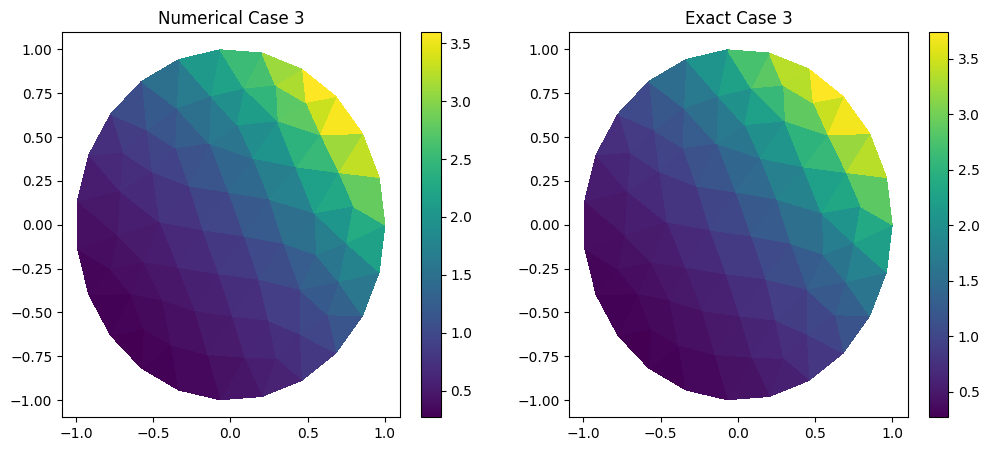

In [6]:
import numpy as np
import gmsh
from mpi4py import MPI
from petsc4py import PETSc
from dolfinx import fem, mesh, plot
import dolfinx.io.gmsh as gmshio
import ufl
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

def solve_poisson_circle(R, alpha, u_ex_expr):
    # 1. GMSH 网格生成
    gmsh.initialize()
    model = gmsh.model()
    gmsh.option.setNumber("General.Terminal", 0)
    model.add("Disk")
    disk = model.occ.addDisk(0, 0, 0, R, R)
    model.occ.synchronize()
    model.addPhysicalGroup(2, [disk], 1)
    model.mesh.generate(2)
    
    mesh_data = gmshio.model_to_mesh(model, MPI.COMM_WORLD, 0, gdim=2)
    msh = mesh_data.mesh
    gmsh.finalize()

    # 2. 函数空间与制造解
    V = fem.functionspace(msh, ("Lagrange", 1))
    x = ufl.SpatialCoordinate(msh)
    
    u_e = u_ex_expr(x)
    f = -ufl.div(ufl.grad(u_e)) + alpha * u_e
    n = ufl.FacetNormal(msh)
    g = ufl.dot(ufl.grad(u_e), n)

    # 3. 标记混合边界
    fdim = msh.topology.dim - 1
    left_facets = mesh.locate_entities_boundary(msh, fdim, lambda x: x[0] <= 1e-14)
    right_facets = mesh.locate_entities_boundary(msh, fdim, lambda x: x[0] >= -1e-14)
    
    indices = np.hstack([left_facets, right_facets])
    values = np.hstack([np.full_like(left_facets, 1), np.full_like(right_facets, 2)])
    order = np.argsort(indices)
    ft = mesh.meshtags(msh, fdim, indices[order], values[order])
    
    ds = ufl.Measure("ds", domain=msh, subdomain_data=ft)
    
    # Dirichlet 条件 (左半圆)
    u_dir = fem.Function(V)
    u_dir.interpolate(fem.Expression(u_e, V.element.interpolation_points))
    bc = fem.dirichletbc(u_dir, fem.locate_dofs_topological(V, fdim, left_facets))

    # 4. 弱形式
    u, v = ufl.TrialFunction(V), ufl.TestFunction(V)
    a = (ufl.dot(ufl.grad(u), ufl.grad(v)) + alpha * u * v) * ufl.dx
    L = f * v * ufl.dx + g * v * ds(2)

    # ---------------------------------------------------------
    # 5. 【修复核心】手动装配 PETSc 矩阵与向量 (专业写法)
    # ---------------------------------------------------------
    a_form = fem.form(a)
    L_form = fem.form(L)

    # 装配矩阵 A
    A = fem.petsc.assemble_matrix(a_form, bcs=[bc])
    A.assemble()

    # 装配向量 b 并应用边界条件
    b = fem.petsc.assemble_vector(L_form)
    fem.petsc.apply_lifting(b, [a_form], [[bc]])
    b.ghostUpdate(addv=PETSc.InsertMode.ADD_VALUES, mode=PETSc.ScatterMode.REVERSE)
    fem.petsc.set_bc(b, [bc])

    # 配置 KSP 求解器 (LU 直接法)
    solver = PETSc.KSP().create(msh.comm)
    solver.setOperators(A)
    solver.setType(PETSc.KSP.Type.PREONLY)
    solver.getPC().setType(PETSc.PC.Type.LU)

    # 求解
    uh = fem.Function(V)
    solver.solve(b, uh.x.petsc_vec)
    uh.x.scatter_forward()
    # ---------------------------------------------------------

    # 6. 计算误差
    u_exact = fem.Function(V)
    u_exact.interpolate(fem.Expression(u_e, V.element.interpolation_points))
    
    diff = uh.x.array - u_exact.x.array
    err_L2 = np.sqrt(msh.comm.allreduce(fem.assemble_scalar(fem.form((uh - u_exact)**2 * ufl.dx)), op=MPI.SUM))
    err_C = np.max(np.abs(diff))
    
    return msh, uh, u_exact, err_L2, err_C

def visualize(msh, uh, u_exact, title_suffix):
    coords = msh.geometry.x[:, :2]
    cells = msh.topology.connectivity(2, 0).array.reshape(-1, 3)
    tri = mtri.Triangulation(coords[:, 0], coords[:, 1], cells)
    
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    c1 = ax[0].tripcolor(tri, uh.x.array, shading='flat', cmap='viridis')
    ax[0].set_title(f"Numerical {title_suffix}")
    fig.colorbar(c1, ax=ax[0])
    
    c2 = ax[1].tripcolor(tri, u_exact.x.array, shading='flat', cmap='viridis')
    ax[1].set_title(f"Exact {title_suffix}")
    fig.colorbar(c2, ax=ax[1])
    plt.show()

# 运行测试函数
test_cases = [
    lambda x: 1.0 + x[0]**2 + 2.0*x[1]**2,
    lambda x: ufl.sin(x[0]) * ufl.cos(x[1]),
    lambda x: ufl.exp(x[0] + x[1])
]

R_val = 1.0
alpha_val = 1.0

for i, expr in enumerate(test_cases):
    msh, uh, u_ex, l2, c_err = solve_poisson_circle(R_val, alpha_val, expr)
    print(f"Case {i+1}: L2 Error = {l2:.2e}, Max Error = {c_err:.2e}")
    visualize(msh, uh, u_ex, f"Case {i+1}")